Ноутбук с обучением модели детекции LLM сгенерированных новостей. Обучение происходит при помощи GAN подхода

* 1. Инициализация

* 2. Подготовка датасета для генератора

* 3. Моделирование

* 4. Финальная оценка качества

In [1]:
from transformers import BertTokenizerFast, BertModel, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from utils_for_colab import try_load, save_s3
from dotenv import load_dotenv
from tqdm.notebook import tqdm
from minio import Minio
from torch import nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


In [2]:
load_dotenv()

YANDEX_CLOUD_ACCESS_KEY = os.getenv("AWS_ACCESS_KEY_ID")
YANDEX_CLOUD_SECRET_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")

BUCKET_NAME = 'graduate' # s3

PATH = '/Users/dan/git_repo/graduate/'

# 1. Инициализация

In [3]:
client_s3 = Minio(
    "storage.yandexcloud.net",
    access_key=YANDEX_CLOUD_ACCESS_KEY,
    secret_key=YANDEX_CLOUD_SECRET_KEY,
    secure=True
)

In [4]:
# Скачаем датасет
train_data = try_load(
    file_path=PATH+'data/',
    file_name='train_data.pkl',
    client_s3=client_s3
    )

test_data = try_load(
    file_path=PATH+'data/',
    file_name='test_data.pkl',
    client_s3=client_s3
    )

In [5]:
# Соберем модель
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
bert = BertModel.from_pretrained(MODEL_NAME)
bert.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

# 2. Подготовка датасета для генератора

In [7]:
class NewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=1024):
        """
        df: pandas.DataFrame с колонками 'news_paper' и 'label'
        tokenizer: экземпляр BertTokenizerFast
        """
        self.texts = df['paper'].tolist()
        self.labels = df['generated_flg'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Токенизируем текст
        encoding = self.tokenizer(
            self.texts[idx],
            add_special_tokens=True,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [8]:
def create_dataset(iteration_num, train_dataset, val_dataset, test_dataset):
  """Функция для формирования датасета для обучения модели GAN подхода

  iteration_num: Номер итерации обучения, 1 - простые новости для детекции, 2 - умеренные, 3 - сложные.
  dataset: Датасет из которого будет проиходить выбор по полю describ
  """

  assert iteration_num in (1,2,3), f'iteration_num должен быть равен 1 или 2 или 3! Текущий равен {iteration_num}'

  if iteration_num == 1:
    describ = ['nyt_orig', 'guardian_orig'] + ['guardian_rw_phi_35']

  elif iteration_num == 2:
    describ = ['nyt_orig', 'guardian_orig'] + ['guardian_rw_phi_35'] \
              + ['guardian_rw_dsv3_1', 'guardian_rw_gemeni_1', 'nyt_rw_dsv3_1', 'dsv3_news_1']

  else:
    describ = ['nyt_orig', 'guardian_orig'] + ['guardian_rw_phi_35'] \
              + ['guardian_rw_dsv3_1', 'guardian_rw_gemeni_1', 'nyt_rw_dsv3_1', 'dsv3_news_1'] \
              + ['guardian_rw_dsv3_2', 'guardian_rw_dsv3_3', 'guardian_rw_dsv3_4',
                 'guardian_rw_dsv3_5', 'guardian_rw_dsv3_6', 'guardian_rw_gemeni_2',
                 'nyt_rw_dsv3_2', 'nyt_rw_dsv3_3', 'nyt_rw_dsv3_4', 'dsv3_news_2']

  return (
      train_dataset[train_dataset['describ'].isin(describ)][['paper', 'generated_flg']].reset_index(drop=True),
      val_dataset[val_dataset['describ'].isin(describ)][['paper', 'generated_flg']].reset_index(drop=True),
      test_dataset[test_dataset['describ'].isin(describ)][['paper', 'generated_flg']].reset_index(drop=True)
      )

# 3. Моделирование

In [45]:
def weighted_accuracy(y_true, y_pred):
    "Функция для оценки взвешанной точности (weighted accuracy)"
    classes = np.unique(y_true)
    weights = np.array([np.sum(y_true == c) for c in classes]) / len(y_true)
    acc_per_class = [accuracy_score(y_true[y_true == c], y_pred[y_true == c]) for c in classes]
    return np.sum(weights * acc_per_class)

In [6]:
class BertBinaryClassifier(nn.Module):
    """Bert + Linerar classification layer"""
    def __init__(self, bert_model, hidden_size=768, dropout=0.2):
        super().__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, 2)  # 2 класса

    def forward(self, input_ids, attention_mask, token_type_ids, labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        # берём [CLS] токен: outputs.last_hidden_state[:,0,:]
        cls_output = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(cls_output)
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)
        return {'loss': loss, 'logits': logits}

In [11]:
def save_checkpoint(model, optimizer, scheduler, epoch, metrics, path="checkpoints", prefix="bert_classifier"):
    """Функция дял сохранения чекпоинта модели"""
    os.makedirs(path, exist_ok=True)
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'epoch': epoch,
        'metrics': metrics,
    }
    filename = f"{prefix}_epoch_{epoch}_auc_{metrics['roc_auc']:.4f}.pt"
    torch.save(checkpoint, os.path.join(path, filename))
    print(f"✅ Checkpoint saved: {filename}")

In [12]:
def train_epoch(
    model,
    loader,
    optimizer,
    scheduler,
    prefix_saved_model,
    val_loader=None,
    val_every: int = 30,
    patience: int = 3,
    epoch=epoch
):
    """
    Тренировка модели в рамках одной эпохи с ранней остановкой по ROC-AUC внутри эпохи.

    Args:
        model: ваша модель с .train()/.eval().
        loader: DataLoader для train.
        optimizer: оптимизатор.
        scheduler: lr-scheduler.
        val_loader: DataLoader для валидации.
        val_every: через сколько батчей делать проверку на валид с ранней остановкой.
        patience: сколько подряд проверок без улучшения ROC-AUC терпеть.
        epoch: Номер эпохи обучения

    Returns:
        avg_train_loss: средний loss на пройденных батчах.
        result: Возвращаем сигнал к продолжению или остановке обучения
    """
    model.train()
    total_loss = 0.0
    running_loss = 0.0

    best_w_precision = 0.0
    no_improve_count = 0

    for step, batch in enumerate(tqdm(loader, desc="Training")):
        # 1) Шаг обучения
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs['loss']
        loss.backward()

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        running_loss += loss.item()

        # 2) Раз в val_every батчей — делаем валидацию и проверяем ROC-AUC
        if val_loader is not None and (step + 1) % val_every == 0:
            avg_run_loss = running_loss / val_every
            metrics = eval_model(
                model=model,
                loader=val_loader
                )

            current_w_precision = metrics['w_precision']

            print(f"[Step {step+1}] Train loss: {avg_run_loss:.4f} | "
                  f"\nVal loss: {metrics['val_loss']:.4f} | "
                  f"W Acc: {metrics['w_accuracy']:.4f} | "
                  f"W Prec: {metrics['w_precision']:.4f} | "
                  f"W Rec: {metrics['w_recall']:.4f} | "
                  f"W F1: {metrics['w_f1_score']:.4f} | "
                  f"\nROC AUC: {metrics['roc_auc']:.4f} | "
                  f"AP: {metrics['average_precision']:.4f}"
                  f"Prec: {metrics['precision']:.4f} | "
                  f"Rec: {metrics['recall']:.4f} | "
                  f"F1: {metrics['f1_score']:.4f} | ")

            # 3) Early stopping логика
            if current_w_precision > best_w_precision:
                best_w_precision = current_w_precision
                no_improve_count = 0

                save_checkpoint(model, optimizer, scheduler, epoch + 1, metrics, prefix_saved_model)

            else:
                no_improve_count += 1
                print(f"→ No improvement for {no_improve_count}/{patience} checks.")
                if no_improve_count >= patience:
                    print("⛔ Early stopping inside epoch triggered.")
                    avg_train_loss = total_loss / (step + 1)
                    return avg_train_loss, 'Early stopping'

            running_loss = 0.0

    if current_w_precision >= best_w_precision:
        best_w_precision = current_w_precision
        no_improve_count = 0

        save_checkpoint(model, optimizer, scheduler, epoch + 1, metrics, prefix_saved_model)

    avg_train_loss = total_loss / (step + 1)
    return avg_train_loss, 'Continue'


def eval_model(model, loader):
    model.eval()
    total_loss = 0

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs['loss']
            logits = outputs['logits']

            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)[:, 1]  # вероятность класса 1
            preds = torch.argmax(logits, dim=1)
            labels = batch['labels']

            all_preds.extend(preds.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)

    # trashhold определим по precision recall curve
    precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)  # F1 для каждого порога
    best_thresh = thresholds[np.argmax(f1_scores)]
    print(f"Лучший порог (по PR-кривой): {best_thresh:.5f}\n")

    roc_auc = roc_auc_score(all_labels, all_probs)
    avg_precision = average_precision_score(all_labels, all_probs)

    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1_score_ = f1_score(all_labels, all_preds, zero_division=0)

    w_accuracy = weighted_accuracy(pd.Series(all_labels), pd.Series(all_preds))
    w_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    w_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    w_f1_score = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    metrics = {
        "val_loss": avg_loss,

        "w_accuracy": w_accuracy,
        "w_precision" : w_precision,
        "w_recall" : w_recall,
        "w_f1_score" : w_f1_score,

        "precision": precision,
        "recall": recall,
        "f1_score" : f1_score_,

        "roc_auc": roc_auc,
        "average_precision": avg_precision
    }

    return metrics

In [14]:
# Подготовим укороченный валидационный датасет
val_data = test_data.sample(frac=0.2)

# Собираем данные для первой итерации
df_train_1, df_val_1, df_test_1 = create_dataset(iteration_num=1, train_dataset=train_data, val_dataset=val_data, test_dataset=test_data)
train_dataset_1 = NewsDataset(df_train_1, tokenizer, max_length=512)
train_loader_1 = DataLoader(train_dataset_1, batch_size=32, shuffle=True)
val_dataset_1 = NewsDataset(df_val_1, tokenizer, max_length=512)
val_loader_1 = DataLoader(val_dataset_1, batch_size=32, shuffle=True)
test_dataset_1 = NewsDataset(df_test_1, tokenizer, max_length=512)
test_loader_1 = DataLoader(test_dataset_1, batch_size=32, shuffle=True)


df_train_2, df_val_2, df_test_2 = create_dataset(iteration_num=2, train_dataset=train_data, val_dataset=val_data, test_dataset=test_data)
train_dataset_2 = NewsDataset(df_train_2, tokenizer, max_length=512)
train_loader_2 = DataLoader(train_dataset_2, batch_size=32, shuffle=True)
val_data_dataset_2 = NewsDataset(df_val_2, tokenizer, max_length=512)
val_data_loader_2 = DataLoader(val_data_dataset_2, batch_size=32, shuffle=True)
test_dataset_2 = NewsDataset(df_test_2, tokenizer, max_length=512)
test_loader_2 = DataLoader(test_dataset_2, batch_size=32, shuffle=True)

df_train_3, df_val_3, df_test_3 = create_dataset(iteration_num=3, train_dataset=train_data, val_dataset=val_data, test_dataset=test_data)
train_dataset_3 = NewsDataset(df_train_3, tokenizer, max_length=512)
train_loader_3 = DataLoader(train_dataset_3, batch_size=32, shuffle=True)
val_dataset_3 = NewsDataset(df_val_3, tokenizer, max_length=512)
val_loader_3 = DataLoader(val_dataset_3, batch_size=32, shuffle=True)
test_dataset_3 = NewsDataset(df_test_3, tokenizer, max_length=512)
test_loader_3 = DataLoader(test_dataset_3, batch_size=32, shuffle=True)

In [15]:
# Инициализируем модель
model = BertBinaryClassifier(bert)
model.to(device)

BertBinaryClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elem

## 3.1 Первый итератор

In [16]:
# Оптимизатор и scheduler
num_epochs = 3

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_loader_1) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [17]:
# Основной цикл
answer = 'Continue'

for epoch in range(num_epochs):

    if answer != 'Continue':
      break

    # Цикл обучения
    train_loss, answer = train_epoch(
        model=model,
        loader=train_loader_1,
        optimizer=optimizer,
        scheduler=scheduler,
        prefix_saved_model='bert_classifier_v1',
        val_loader=val_loader_1,
        val_every=30,
        patience=3,
        epoch=epoch
        )

#############
print(f'========= Final check (dataset 1) =========')

metrics = eval_model(
    model=model,
    loader=test_loader_1
    )

print(f"\nVal loss: {metrics['val_loss']:.4f} | "
      f"W Acc: {metrics['w_accuracy']:.4f} | "
      f"W Prec: {metrics['w_precision']:.4f} | "
      f"W Rec: {metrics['w_recall']:.4f} | "
      f"W F1: {metrics['w_f1_score']:.4f} | "
      f"ROC AUC: {metrics['roc_auc']:.4f} | "
      f"AP: {metrics['average_precision']:.4f}"
      f"Prec: {metrics['precision']:.4f} | "
      f"Rec: {metrics['recall']:.4f} | "
      f"F1: {metrics['f1_score']:.4f} | ")
print()


print(f'========= Final check (dataset 2) =========')

metrics = eval_model(
    model=model,
    loader=test_loader_2
    )

print(f"\nVal loss: {metrics['val_loss']:.4f} | "
      f"W Acc: {metrics['w_accuracy']:.4f} | "
      f"W Prec: {metrics['w_precision']:.4f} | "
      f"W Rec: {metrics['w_recall']:.4f} | "
      f"W F1: {metrics['w_f1_score']:.4f} | "
      f"ROC AUC: {metrics['roc_auc']:.4f} | "
      f"AP: {metrics['average_precision']:.4f}"
      f"Prec: {metrics['precision']:.4f} | "
      f"Rec: {metrics['recall']:.4f} | "
      f"F1: {metrics['f1_score']:.4f} | ")
print()

print(f'========= Final check (dataset 3) =========')

metrics = eval_model(
    model=model,
    loader=test_loader_3
    )

print(f"\nVal loss: {metrics['val_loss']:.4f} | "
      f"W Acc: {metrics['w_accuracy']:.4f} | "
      f"W Prec: {metrics['w_precision']:.4f} | "
      f"W Rec: {metrics['w_recall']:.4f} | "
      f"W F1: {metrics['w_f1_score']:.4f} | "
      f"ROC AUC: {metrics['roc_auc']:.4f} | "
      f"AP: {metrics['average_precision']:.4f}"
      f"Prec: {metrics['precision']:.4f} | "
      f"Rec: {metrics['recall']:.4f} | "
      f"F1: {metrics['f1_score']:.4f} | ")
print()

Training:   0%|          | 0/198 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Лучший порог (по PR-кривой): 0.29040

[Step 30] Train loss: 0.5448 | 
Val loss: 0.3103 | W Acc: 0.8121 | W Prec: 0.6595 | W Rec: 0.8121 | W F1: 0.7279 | 
ROC AUC: 0.9996 | AP: 0.9983Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | 
✅ Checkpoint saved: bert_classifier_epoch_1_auc_0.9996.pt


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Лучший порог (по PR-кривой): 0.79034

[Step 60] Train loss: 0.1310 | 
Val loss: 0.0069 | W Acc: 1.0000 | W Prec: 1.0000 | W Rec: 1.0000 | W F1: 1.0000 | 
ROC AUC: 1.0000 | AP: 1.0000Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | 
✅ Checkpoint saved: bert_classifier_epoch_1_auc_1.0000.pt


...

Лучший порог (по PR-кривой): 0.83096


Val loss: 0.0017 | W Acc: 1.0000 | W Prec: 1.0000 | W Rec: 1.0000 | W F1: 1.0000 | ROC AUC: 1.0000 | AP: 1.0000Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | 

========= Final check (dataset 2) =========


Evaluating:   0%|          | 0/91 [00:00<?, ?it/s]

Лучший порог (по PR-кривой): 0.00104


Val loss: 1.6564 | W Acc: 0.6135 | W Prec: 0.7969 | W Rec: 0.6135 | W F1: 0.5751 | ROC AUC: 0.9780 | AP: 0.9873Prec: 1.0000 | Rec: 0.3245 | F1: 0.4900 | 

========= Final check (dataset 3) =========


Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

Лучший порог (по PR-кривой): 0.00061


Val loss: 3.1111 | W Acc: 0.3578 | W Prec: 0.8511 | W Rec: 0.3578 | W F1: 0.3454 | ROC AUC: 0.9574 | AP: 0.9902Prec: 1.0000 | Rec: 0.2033 | F1: 0.3380 | 



## 3.2 Второй итератор

In [18]:
# Оптимизатор и scheduler
num_epochs = 3

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_loader_2) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [19]:
# Основной цикл
answer = 'Continue'

for epoch in range(num_epochs):

    if answer != 'Continue':
      break

    # Цикл обучения
    train_loss, answer = train_epoch(
        model=model,
        loader=train_loader_2,
        optimizer=optimizer,
        scheduler=scheduler,
        prefix_saved_model='bert_classifier_v2',
        val_loader=val_data_loader_2,
        val_every=30,
        patience=3,
        )

#############

print(f'========= Final check (dataset 1) =========')

metrics = eval_model(
    model=model,
    loader=test_loader_1
    )

print(f"\nVal loss: {metrics['val_loss']:.4f} | "
      f"W Acc: {metrics['w_accuracy']:.4f} | "
      f"W Prec: {metrics['w_precision']:.4f} | "
      f"W Rec: {metrics['w_recall']:.4f} | "
      f"W F1: {metrics['w_f1_score']:.4f} | "
      f"ROC AUC: {metrics['roc_auc']:.4f} | "
      f"AP: {metrics['average_precision']:.4f}"
      f"Prec: {metrics['precision']:.4f} | "
      f"Rec: {metrics['recall']:.4f} | "
      f"F1: {metrics['f1_score']:.4f} | ")
print()


print(f'========= Final check (dataset 2) =========')

metrics = eval_model(
    model=model,
    loader=test_loader_2
    )

print(f"\nVal loss: {metrics['val_loss']:.4f} | "
      f"W Acc: {metrics['w_accuracy']:.4f} | "
      f"W Prec: {metrics['w_precision']:.4f} | "
      f"W Rec: {metrics['w_recall']:.4f} | "
      f"W F1: {metrics['w_f1_score']:.4f} | "
      f"ROC AUC: {metrics['roc_auc']:.4f} | "
      f"AP: {metrics['average_precision']:.4f}"
      f"Prec: {metrics['precision']:.4f} | "
      f"Rec: {metrics['recall']:.4f} | "
      f"F1: {metrics['f1_score']:.4f} | ")
print()

print(f'========= Final check (dataset 3) =========')

metrics = eval_model(
    model=model,
    loader=test_loader_3
    )

print(f"\nVal loss: {metrics['val_loss']:.4f} | "
      f"W Acc: {metrics['w_accuracy']:.4f} | "
      f"W Prec: {metrics['w_precision']:.4f} | "
      f"W Rec: {metrics['w_recall']:.4f} | "
      f"W F1: {metrics['w_f1_score']:.4f} | "
      f"ROC AUC: {metrics['roc_auc']:.4f} | "
      f"AP: {metrics['average_precision']:.4f}"
      f"Prec: {metrics['precision']:.4f} | "
      f"Rec: {metrics['recall']:.4f} | "
      f"F1: {metrics['f1_score']:.4f} | ")
print()

Training:   0%|          | 0/361 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Лучший порог (по PR-кривой): 0.94137

[Step 30] Train loss: 0.6749 | 
Val loss: 0.0919 | W Acc: 0.9620 | W Prec: 0.9629 | W Rec: 0.9620 | W F1: 0.9619 | 
ROC AUC: 0.9971 | AP: 0.9980Prec: 0.9467 | Rec: 0.9877 | F1: 0.9668 | 
✅ Checkpoint saved: bert_classifier_epoch_1_auc_0.9971.pt


Evaluating:   0%|          | 0/19 [00:00<?, ?it/s]

Лучший порог (по PR-кривой): 0.55741

[Step 60] Train loss: 0.0612 | 
Val loss: 0.0304 | W Acc: 0.9879 | W Prec: 0.9879 | W Rec: 0.9879 | W F1: 0.9879 | 
ROC AUC: 0.9995 | AP: 0.9996Prec: 0.9847 | Rec: 0.9938 | F1: 0.9892 | 
✅ Checkpoint saved: bert_classifier_epoch_1_auc_0.9995.pt


...

Лучший порог (по PR-кривой): 0.99924


Val loss: 0.0009 | W Acc: 1.0000 | W Prec: 1.0000 | W Rec: 1.0000 | W F1: 1.0000 | ROC AUC: 1.0000 | AP: 1.0000Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | 

========= Final check (dataset 2) =========


Evaluating:   0%|          | 0/91 [00:00<?, ?it/s]

Лучший порог (по PR-кривой): 0.03092


Val loss: 0.0115 | W Acc: 0.9965 | W Prec: 0.9966 | W Rec: 0.9965 | W F1: 0.9966 | ROC AUC: 1.0000 | AP: 1.0000Prec: 1.0000 | Rec: 0.9940 | F1: 0.9970 | 

========= Final check (dataset 3) =========


Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

Лучший порог (по PR-кривой): 0.00512


Val loss: 0.0772 | W Acc: 0.9773 | W Prec: 0.9797 | W Rec: 0.9773 | W F1: 0.9778 | ROC AUC: 0.9994 | AP: 0.9999Prec: 1.0000 | Rec: 0.9719 | F1: 0.9857 | 



## 3.3 Третий итератор

In [20]:
# Оптимизатор и scheduler
num_epochs = 3

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_loader_3) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [21]:
# Основной цикл
answer = 'Continue'

for epoch in range(num_epochs):

    if answer != 'Continue':
      break

    # Цикл обучения
    train_loss, answer = train_epoch(
        model=model,
        loader=train_loader_3,
        optimizer=optimizer,
        scheduler=scheduler,
        prefix_saved_model='bert_classifier_v3',
        val_loader=val_loader_3,
        val_every=30,
        patience=3,
        )

#############

print(f'========= Final check (dataset 1) =========')

metrics = eval_model(
    model=model,
    loader=test_loader_1
    )

print(f"\nVal loss: {metrics['val_loss']:.4f} | "
      f"W Acc: {metrics['w_accuracy']:.4f} | "
      f"W Prec: {metrics['w_precision']:.4f} | "
      f"W Rec: {metrics['w_recall']:.4f} | "
      f"W F1: {metrics['w_f1_score']:.4f} | "
      f"ROC AUC: {metrics['roc_auc']:.4f} | "
      f"AP: {metrics['average_precision']:.4f}"
      f"Prec: {metrics['precision']:.4f} | "
      f"Rec: {metrics['recall']:.4f} | "
      f"F1: {metrics['f1_score']:.4f} | ")
print()


print(f'========= Final check (dataset 2) =========')

metrics = eval_model(
    model=model,
    loader=test_loader_2
    )

print(f"\nVal loss: {metrics['val_loss']:.4f} | "
      f"W Acc: {metrics['w_accuracy']:.4f} | "
      f"W Prec: {metrics['w_precision']:.4f} | "
      f"W Rec: {metrics['w_recall']:.4f} | "
      f"W F1: {metrics['w_f1_score']:.4f} | "
      f"ROC AUC: {metrics['roc_auc']:.4f} | "
      f"AP: {metrics['average_precision']:.4f}"
      f"Prec: {metrics['precision']:.4f} | "
      f"Rec: {metrics['recall']:.4f} | "
      f"F1: {metrics['f1_score']:.4f} | ")
print()

print(f'========= Final check (dataset 3) =========')

metrics = eval_model(
    model=model,
    loader=test_loader_3
    )

print(f"\nVal loss: {metrics['val_loss']:.4f} | "
      f"W Acc: {metrics['w_accuracy']:.4f} | "
      f"W Prec: {metrics['w_precision']:.4f} | "
      f"W Rec: {metrics['w_recall']:.4f} | "
      f"W F1: {metrics['w_f1_score']:.4f} | "
      f"ROC AUC: {metrics['roc_auc']:.4f} | "
      f"AP: {metrics['average_precision']:.4f}"
      f"Prec: {metrics['precision']:.4f} | "
      f"Rec: {metrics['recall']:.4f} | "
      f"F1: {metrics['f1_score']:.4f} | ")

Training:   0%|          | 0/797 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Лучший порог (по PR-кривой): 0.89345

[Step 30] Train loss: 0.0409 | 
Val loss: 0.0192 | W Acc: 0.9937 | W Prec: 0.9937 | W Rec: 0.9937 | W F1: 0.9937 | 
ROC AUC: 0.9999 | AP: 1.0000Prec: 0.9942 | Rec: 0.9980 | F1: 0.9961 | 
✅ Checkpoint saved: bert_classifier_epoch_1_auc_0.9999.pt


Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Лучший порог (по PR-кривой): 0.26428

[Step 60] Train loss: 0.0040 | 
Val loss: 0.0101 | W Acc: 0.9961 | W Prec: 0.9961 | W Rec: 0.9961 | W F1: 0.9961 | 
ROC AUC: 0.9999 | AP: 1.0000Prec: 0.9990 | Rec: 0.9961 | F1: 0.9976 | 
✅ Checkpoint saved: bert_classifier_epoch_1_auc_0.9999.pt


...

Лучший порог (по PR-кривой): 0.99926


Val loss: 0.0024 | W Acc: 1.0000 | W Prec: 1.0000 | W Rec: 1.0000 | W F1: 1.0000 | ROC AUC: 1.0000 | AP: 1.0000Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | 

========= Final check (dataset 2) =========


Evaluating:   0%|          | 0/91 [00:00<?, ?it/s]

Лучший порог (по PR-кривой): 0.54646


Val loss: 0.0081 | W Acc: 0.9986 | W Prec: 0.9986 | W Rec: 0.9986 | W F1: 0.9986 | ROC AUC: 0.9999 | AP: 0.9999Prec: 1.0000 | Rec: 0.9976 | F1: 0.9988 | 

========= Final check (dataset 3) =========


Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

Лучший порог (по PR-кривой): 0.54646


Val loss: 0.0047 | W Acc: 0.9991 | W Prec: 0.9991 | W Rec: 0.9991 | W F1: 0.9991 | ROC AUC: 1.0000 | AP: 1.0000Prec: 1.0000 | Rec: 0.9988 | F1: 0.9994 | 


# 4. Финальная оценка качества

In [7]:
checkpoint = torch.load(
    "/content/bert_classifier_v3/bert_classifier_epoch_1_auc_1.0000.pt",
    weights_only=False
)
print(checkpoint.keys())

dict_keys(['model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'epoch', 'metrics'])


In [9]:
# 1. Создаём модель (архитектура должна совпадать с сохранённой)
model = BertBinaryClassifier(bert)

# 2. Загружаем веса в модель
model.load_state_dict(
    checkpoint['model_state_dict']
    )

# переводим модель в режим предсказания (отключает dropout и т. д.)
model.to(device)
model.eval()

BertBinaryClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elem

In [55]:
ttl_prob = list()
input_ids_mem = list()

for i in tqdm(range(0, len(test_data['paper']), 32)):

  batch = test_data['paper'][i:i+32]

  encoding = tokenizer(
    list(batch),
    add_special_tokens=True,
    truncation=True,
    max_length=512,
    padding='max_length',
    return_tensors='pt'
  )

  item = {key: val.to(device) for key, val in encoding.items()}

  with torch.no_grad():
    out = model(**item)

  logits = out['logits']
  prob_1_class = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

  input_ids_mem.append(item['input_ids'].detach().cpu().numpy())
  ttl_prob.append(prob_1_class)

  0%|          | 0/200 [00:00<?, ?it/s]

In [61]:
input_ids_mem = pd.DataFrame(np.vstack(input_ids_mem))

In [64]:
# Получение вероятностей и меток класса на тестовом наборе
y_prob = pd.Series()
for batch in ttl_prob:
  y_prob = pd.concat([y_prob, pd.Series(batch)])

y_pred = [1 if x > 0.5 else 0 for x in y_prob]

test_data['model_lable'] = y_pred
test_data['model_score'] = list(y_prob)

<ipython-input-64-056fb14a3b2a>:4: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  y_prob = pd.concat([y_prob, pd.Series(batch)])


In [65]:
# trashhold определим по precision recall curve
precision, recall, thresholds = precision_recall_curve(test_data['generated_flg'], test_data['model_score'])
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)  # F1 для каждого порога
best_thresh_v2 = thresholds[np.argmax(f1_scores)]
print(f"Лучший порог (по PR-кривой): {best_thresh_v2:.5f}\n")

# Метрики
print(f"ROC-AUC: {roc_auc_score(test_data['generated_flg'], test_data['model_score']):.5f}")
print(f"Average_precision_score: {average_precision_score(test_data['generated_flg'], test_data['model_score']):.5f}\n")

print(f"Accuracy W: {weighted_accuracy(test_data['generated_flg'], test_data['model_lable']):.3f}")
print(f"Precision W: {precision_score(test_data['generated_flg'], test_data['model_lable'], average='weighted', zero_division=np.nan):.5f}")
print(f"Recall W: {recall_score(test_data['generated_flg'], test_data['model_lable'], average='weighted', zero_division=np.nan):.5f}")
print(f"F1-score W: {f1_score(test_data['generated_flg'], test_data['model_lable'], average='weighted', zero_division=np.nan):.5f}\n")

print(f"Precision: {precision_score(test_data['generated_flg'], test_data['model_lable']):.5f}")
print(f"Recall: {recall_score(test_data['generated_flg'], test_data['model_lable']):.5f}")
print(f"F1-score: {f1_score(test_data['generated_flg'], test_data['model_lable']):.5f}")

Лучший порог (по PR-кривой): 0.61940

ROC-AUC: 0.99991
Average_precision_score: 0.99998

Accuracy W: 0.996
Precision W: 0.99563
Recall W: 0.99562
F1-score W: 0.99561

Precision: 0.99517
Recall: 0.99942
F1-score: 0.99729


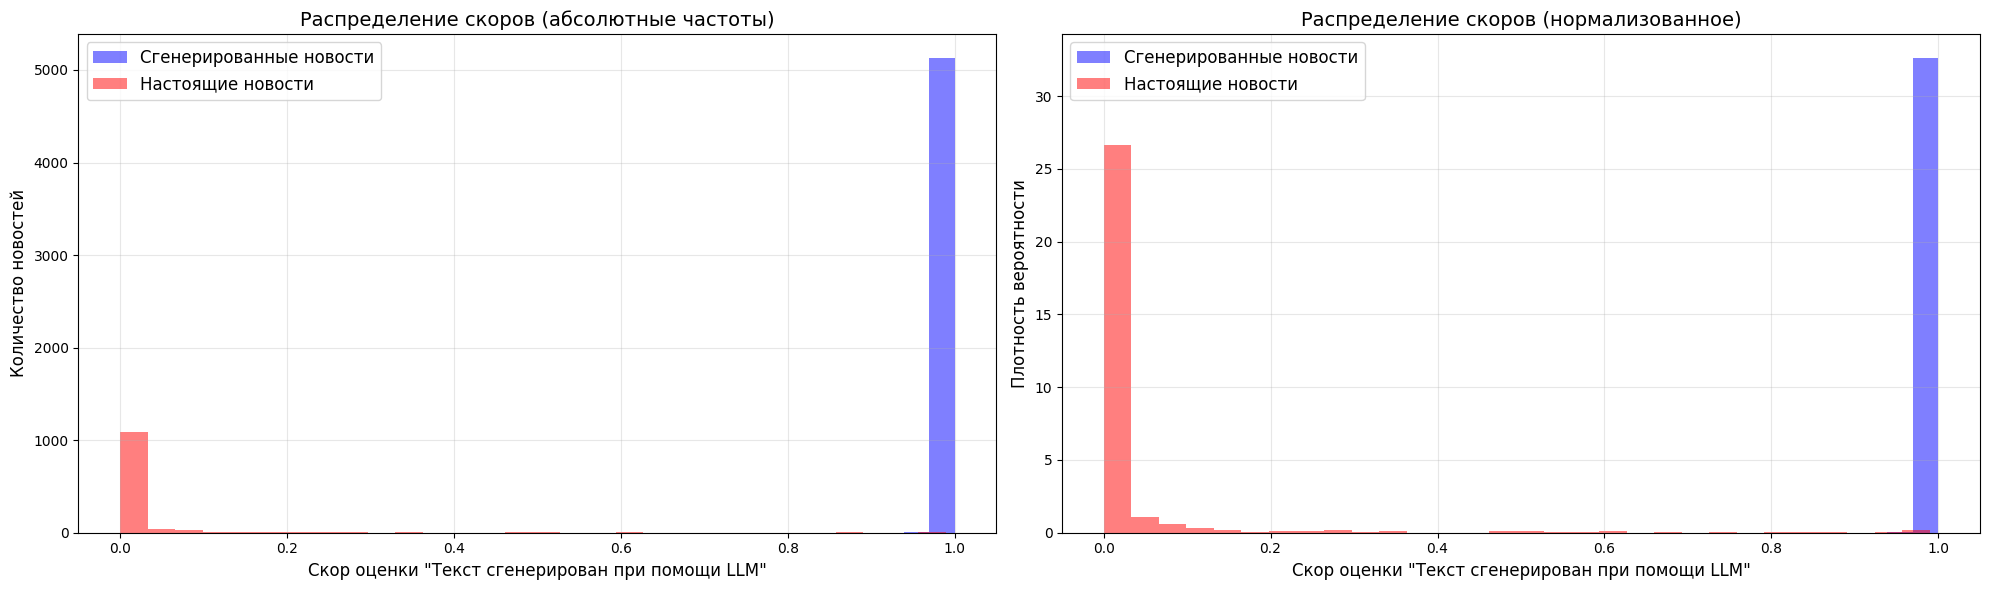

In [52]:
# Подготовим данные для графика
result_gen = test_data[test_data['generated_flg']==1][['model_score']]
result_orig = test_data[test_data['generated_flg']==0][['model_score']]

# График
plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)

result_gen['model_score'].hist(bins=30,
                           alpha=0.5,
                           color='blue',
                           label='Сгенерированные новости')

result_orig['model_score'].hist(bins=30,
                             alpha=0.5,
                             color='red',
                             label='Настоящие новости')

plt.title('Распределение скоров (абсолютные частоты)', fontsize=14)
plt.xlabel('Скор оценки "Текст сгенерирован при помощи LLM"', fontsize=12)
plt.ylabel('Количество новостей', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)

result_gen['model_score'].hist(bins=30,
                           alpha=0.5,
                           color='blue',
                           label='Сгенерированные новости',
                           density=True)

result_orig['model_score'].hist(bins=30,
                             alpha=0.5,
                             color='red',
                             label='Настоящие новости',
                             density=True)

plt.title('Распределение скоров (нормализованное)', fontsize=14)
plt.xlabel('Скор оценки "Текст сгенерирован при помощи LLM"', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
test_data = pd.concat([test_data, input_ids_mem], axis=1)
save_s3(pickle_data=test_data, object_key='test_data_gan.pkl', client_s3=client_s3)

# 5. Пример инференса

In [ ]:
# Инициализация класса модели
class BertBinaryClassifier(nn.Module):
    def __init__(self, bert_model, hidden_size=768, dropout=0.2):
        super().__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, 2)  # 2 класса

    def forward(self, input_ids, attention_mask, token_type_ids, labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        # берём [CLS] токен: outputs.last_hidden_state[:,0,:]
        cls_output = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(cls_output)
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)
        return {'loss': loss, 'logits': logits}

In [ ]:
# Загружаем весов в модель, перенос на device и режим eval
checkpoint = torch.load(
    "/content/bert_classifier_v3/bert_classifier_epoch_1_auc_1.0000.pt",
    weights_only=False
)

model = BertBinaryClassifier(bert)

model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

In [80]:
def predict_paper(paper, tokenizer=tokenizer, model=model):
  '''Функция для определение вероятности генерации статьи при помощи LLM
  
    paper: Текст новостной статьи
    tokenizer: bert-base-uncased tokenizer
    model: BertBinaryClassifier
  
    Return : float 
  '''
  encoding = tokenizer(
    paper,
    add_special_tokens=True,
    truncation=True,
    max_length=512,
    padding='max_length',
    return_tensors='pt'
  )

  item = {key: val.to(device) for key, val in encoding.items()}

  with torch.no_grad():
    out = model(**item)

  logits = out['logits']
  prob_1_class = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

  return float(prob_1_class[0])

In [2]:
# original
paper = '''
Robert Fico and Aleksandar Vučić accept Vladimir Putin’s invitation to attend Victory Day celebrations
Despite warnings from European Union officials, Slovakia’s Moscow-friendly prime minister, Robert Fico, shook hands with Vladimir Putin at the Kremlin before becoming the only EU leader to attend Russia’s 9 May parade of military forces waging war on Ukraine.
The Serbian president, Aleksandar Vučić, whose country aspires to join the 27-nation union, also accepted the Russian president’s invitation to attend the annual Victory Day celebrations marking the defeat of Nazi Germany in the second world war.
The pair were the only European leaders to travel to Moscow after strong injunctions from EU officials not to do so. On Thursday, the bloc’s chief diplomat, Kaja Kallas, said: “All those who truly support peace cannot stand side-by-side with Putin. Those who truly support peace should be in Ukraine tomorrow, not Moscow.”
Kallas added this week that the Russian president was “waging a war right now, not a war from history. That remains on the conscience of those attending.”
Poland’s prime minister, Donald Tusk, who later on Friday was due to sign a cooperation and friendship treaty with France including joint security and defence commitments, sharply criticised both leaders, although he did so without naming them.
Tusk said: “For me it is unthinkable that one can be from this part of the world and, during Russia’s aggression against Ukraine, be in Red Square and celebrate Victory Day with those who are murdering children, civilians and attacking other countries.”
It is unclear what, if any, sanctions the EU could apply to either Bratislava or Belgrade. António Costa, the president of the European Council, is due to visit the Serbian capital on Monday. An EU official in Brussels suggested he would express criticism of the visits, saying: “We don’t engage only to pass easy and good messages.”
Kallas said last month that participation in the 9 May celebrations in Moscow would “not be taken lightly on the European side”. She called on representatives of EU member states and candidate countries to mark the day in Ukraine instead.
The EU foreign affairs chief was one of a 17-strong delegation of EU officials and foreign ministers, which also included the British foreign secretary, David Lammy, in Lviv on Friday to honour the victims of Russia’s war and back a special tribunal to investigate alleged Russian war crimes.
Fico, who last met Putin in December, said in April that “nobody will tell me where to go and where not to go”. He said he was going to “a commemorative event, that’s all”, to “pay homage to thousands of Red Army soldiers who died liberating Slovakia”.
The Slovakian prime minister, who has adopted Kremlin lines and sided with Hungary’s illiberal leader, Viktor Orbán, as a pro-Russian voice in the EU, also took part in bilateral meetings and attended a wreath-laying ceremony in Moscow.
'''.replace('\n', ' ')

prob_llm_gen = predict_paper(paper)

print(f'Вероятность генерации LLM: {prob_llm_gen}')

Вероятность генерации LLM: 0.0019998583011329174


In [83]:
# original
paper = '''
Moscow stages largest Victory Day parade since start of Ukraine war with Putin using celebrations to justify invasion
Pjotr Sauer, and Shaun Walker in Kyiv

Russian troops fighting in Ukraine have marched with Chinese forces on Moscow’s Red Square to mark the 80th anniversary of Nazi Germany’s defeat in a Victory Day celebration marked by greater spectacle than in recent years.

After several scaled-back Victory Days – with reduced military displays and few foreign guests – Vladimir Putin on Friday addressed the largest parade since his 2022 full-scale invasion of Ukraine.

“The Soviet Union took upon itself the most ferocious, merciless blows of the enemy,” the Russian president said of the victory over Nazi Germany, before turning to his invasion of Ukraine. “Truth and justice are on our side. The entire country, society and people support the participants of the special military operation,” Putin said, using the Kremlin’s preferred term to describe the war.

While Putin was presiding over the parade, EU foreign ministers and Britain’s David Lammy travelled to Lviv in Ukraine where they announced the establishment of a tribunal for Russian war crimes. “Russia’s aggression cannot go unpunished and therefore establishing this tribunal is extremely important,” the EU’s top diplomat, Kaja Kallas, said during the visit.

Ukraine’s president, Volodymyr Zelenskyy, said he expected European leaders to visit Kyiv on Saturday, while European allies said at a meeting in Oslo that they supported an unconditional 30-day ceasefire in the war in Ukraine, something Moscow has been reluctant to agree to.

Moscow welcomed at least 27 foreign heads to the annual military parade, the highest number since 2015, including the leaders of Brazil, Slovakia and Serbia. The Kremlin presented the turnout as proof that it is not isolated, even four years into its war in Ukraine.

Other guests included leaders from fellow autocracies and pariah regimes, such as the military juntas from Myanmar and Burkina Faso.

Putin also thanked a visiting North Korean military delegation – a sign of deepening ties and new geopolitical realities after recent admissions from both sides that North Korean troops have been fighting alongside Russian forces in Ukraine.
'''.replace('\n', ' ')

prob_llm_gen = predict_paper(paper)

print(f'Вероятность генерации LLM: {prob_llm_gen}')

Вероятность генерации LLM: 0.01601441204547882


In [84]:
# generated
paper = '''
Slovakian and Serbian Leaders Defy EU Warnings to Attend Russian Military Parade

Bratislava/Belgrade, May 9, 2024 – In a move likely to strain relations with the European Union, Slovak Prime Minister Robert Fico and Serbian President Aleksandar Vučić attended Russia’s Victory Day military parade in Moscow, despite explicit disapproval from Brussels. The event, marking the Soviet Union’s victory over Nazi Germany in World War II, has become a symbol of Russian military might under President Vladimir Putin, who hosted the leaders amid ongoing tensions over the war in Ukraine.

Defiance Amid Diplomatic Tensions

The participation of Fico and Vučić signals a deliberate pivot toward Moscow, challenging the EU’s unified stance on isolating Russia. While most Western leaders boycotted the event, the Slovak and Serbian leaders’ presence underscores deepening divisions within Europe over relations with the Kremlin.

Fico, who has repeatedly criticized Western military aid to Ukraine, called the parade a "historic commemoration" and emphasized Slovakia’s "independent foreign policy."
Vučić, whose country remains an EU candidate but maintains close ties with Russia, praised "the sacrifices of the Soviet people" while avoiding direct mention of Ukraine.
EU Reaction: Frustration and Warnings

European officials expressed dismay, with one EU diplomat stating, "This is a provocation at a time when solidarity with Ukraine is crucial." While no immediate sanctions are expected, the move could complicate Slovakia’s and Serbia’s relations with Brussels, particularly as Serbia faces pressure to align with EU foreign policy.

Kremlin’s Symbolic Victory

Putin’s invitation to the leaders was seen as an attempt to showcase Russia’s enduring influence in Eastern Europe. State media highlighted their attendance as evidence that Western efforts to isolate Moscow have failed.

What’s Next?
Analysts suggest the EU may respond with stricter scrutiny of Serbia’s accession talks and Slovakia’s pro-Russian rhetoric. Meanwhile, the spectacle reinforces fears of a growing geopolitical rift in the Balkans and Central Europe.
'''.replace('\n', ' ')

prob_llm_gen = predict_paper(paper)

print(f'Вероятность генерации LLM: {prob_llm_gen}')

Вероятность генерации LLM: 0.9997710585594177


In [85]:
# generated
paper = '''
In a powerful display of military cooperation and diplomatic solidarity, Chinese troops marched alongside Russian forces through Moscow's Red Square on Thursday, marking the annual Victory Day parade. President Xi Jinping stood beside Russian President Vladimir Putin, underscoring the strengthening ties between the two nations amid heightened tensions with the West.

The parade commemorates the Soviet Union’s victory over Nazi Germany in World War II, and this year’s event carried added geopolitical symbolism. For the first time in several years, a significant Chinese military contingent participated in the procession, drawing global attention.

“Our cooperation knows no bounds,” President Xi stated in a brief address after the parade. “We honor the past, and together we are prepared for the future.”

The joint appearance follows a series of high-level meetings and military drills between the two countries, fueling speculation about a deepening strategic alliance. Western analysts view the gesture as a message to NATO and a reaffirmation of the Sino-Russian partnership.

Victory Day celebrations included not only the traditional military parade but also a moment of silence, wreath-laying ceremonies, and a flyover by the Russian Air Force. Crowds gathered in central Moscow, waving flags and cheering as the two leaders watched the event unfold from the grandstand.
'''.replace('\n', ' ')


prob_llm_gen = predict_paper(paper)

print(f'Вероятность генерации LLM: {prob_llm_gen}')

Вероятность генерации LLM: 0.9989556074142456
